In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## Function to convert the jsonl to csv file by keeping only necessary columns

In [3]:
def convertTocsv(filePath, fileType, roundType):
    """
    Convert a JSON file to a CSV file with specific formatting.

    Parameters:
    filePath (str): The path to the JSON file to be converted.
    fileType (str): The type of the file, used in the output file name.
    roundType (str): The round type, used in the output file name.

    Returns:
    None

    The function reads a JSON file, selects specific columns, renames them, 
    and then writes the data to a CSV file with a name based on the fileType 
    and roundType parameters.
    """
    # Your code here
    df = pd.read_json(filePath, lines=True)
    df = df[['sentence', 'gold_label']]
    df = df.rename(columns={'sentence': 'text', 'gold_label': 'label'})
    df.to_csv(f"modified_data\dynasent-{roundType}-{fileType}.csv", index=False)

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
C:\Users\neerajdattu.dudam\AppData\Local\Temp\ipykernel_10180\285500984.py:5: SyntaxWarning: invalid escape sequence '\d'
  df.to_csv(f"modified_data\dynasent-{roundType}-{fileType}.csv", index=False)


In [4]:
# List of types to process
type = ['dev', 'test', 'train']

# Iterate through each type
for t in type:
    # Define file paths for yelp and dynabench JSON files
    yelp = f"data\dynasent-v1.1-round01-yelp-{t}.jsonl"
    dynabench = f"data\dynasent-v1.1-round02-dynabench-{t}.jsonl"
    
    # Convert yelp JSON file to CSV
    convertTocsv(yelp, t, 'yelp')
    
    # Convert dynabench JSON file to CSV
    convertTocsv(dynabench, t, 'dynabench')

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\neerajdattu.dudam\AppData\Local\Temp\ipykernel_10180\709087995.py:3: SyntaxWarning: invalid escape sequence '\d'
  yelp = f"data\dynasent-v1.1-round01-yelp-{t}.jsonl"
C:\Users\neerajdattu.dudam\AppData\Local\Temp\ipykernel_10180\709087995.py:4: SyntaxWarning: invalid escape sequence '\d'
  dynabench = f"data\dynasent-v1.1-round02-dynabench-{t}.jsonl"


## Function to plot missing values summary

In [14]:
def plot_missing_values_summary():
    # Directory containing the CSV files
    csv_dir = "modified_data"

    # List to store the results
    missing_values_summary = []

    # Iterate through each CSV file in the directory
    for file_name in os.listdir(csv_dir):
        if file_name.endswith(".csv"):
            file_path = os.path.join(csv_dir, file_name)
            df = pd.read_csv(file_path)

            # Count missing values in 'text' and 'label' columns
            missing_text = df['text'].isna().sum()
            missing_label = df['label'].isna().sum()

            # Append the results to the summary list
            missing_values_summary.append({
                'file_name': file_name,
                'missing_text': missing_text,
                'missing_label': missing_label
            })

    # Convert the summary list to a DataFrame for better visualization
    missing_values_df = pd.DataFrame(missing_values_summary)

    # Plot the table
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=missing_values_df.values, colLabels=missing_values_df.columns, cellLoc='center', loc='center')
    ax.set_title('Missing Values Summary')
    table.auto_set_font_size(True)
    table.set_fontsize(16)
    table.scale(1.2, 1.2)
    plt.show()

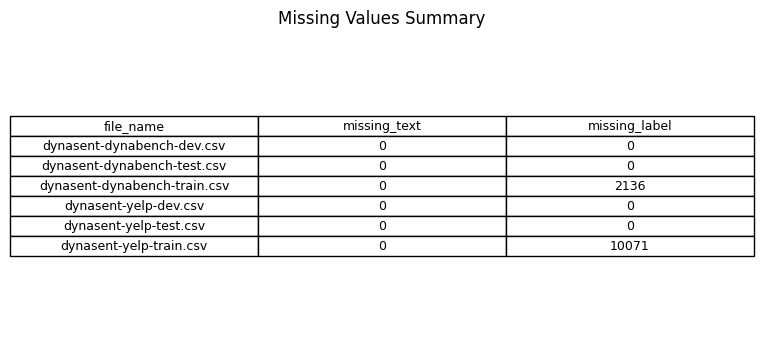

In [15]:
plot_missing_values_summary()

## Remove the rows of missing values

In [16]:
# Iterate through each CSV file in the directory
for file_name in os.listdir("modified_data"):
    if file_name.endswith(".csv"):
        file_path = os.path.join("modified_data", file_name)
        df = pd.read_csv(file_path)
        
        # Drop rows with missing values in 'text' and 'label' columns
        df = df.dropna(subset=['text', 'label'])
        
        # Save the cleaned dataframe back to the CSV file
        df.to_csv(file_path, index=False)

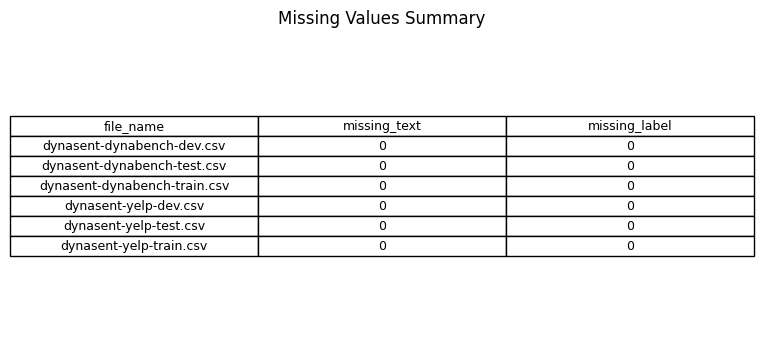

In [17]:
plot_missing_values_summary()

## Print the data summary to check the distribution

In [36]:
def print_rows_summary():
    # Directory containing the CSV files
    csv_dir = "modified_data"

    # List to store the results
    rows_summary = []
    # Iterate through each CSV file in the directory
    for file_name in os.listdir(csv_dir):
        if file_name.endswith(".csv"):
            file_path = os.path.join(csv_dir, file_name)
            df = pd.read_csv(file_path)

            # Count total rows and rows for each label
            total_rows = len(df)
            positive_rows = len(df[df['label'] == 'positive'])
            negative_rows = len(df[df['label'] == 'negative'])
            mixed_rows = len(df[df['label'] == 'mixed'])
            neutral_rows = len(df[df['label'] == 'neutral'])

            # Append the results to the summary list
            rows_summary.append({
                'file_name': file_name,
                'total_rows': total_rows,
                'positive_rows': positive_rows,
                'negative_rows': negative_rows,
                'mixed_rows': mixed_rows,
                'neutral_rows': neutral_rows
            })

    # Convert the summary list to a DataFrame for better visualization
    rows_summary_df = pd.DataFrame(rows_summary)

    # Plot the table
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=rows_summary_df.values, colLabels=rows_summary_df.columns, cellLoc='center', loc='center')
    ax.set_title('Rows Summary')
    table.auto_set_font_size(True)
    table.set_fontsize(14)
    table.scale(1.2, 1.2)
    plt.show()
    return rows_summary_df

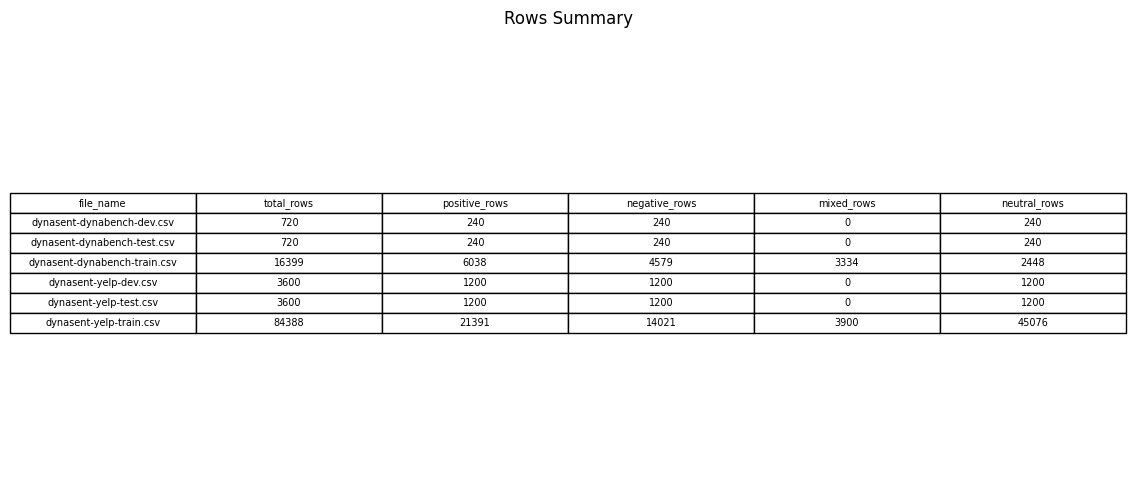

In [37]:
rows_summary_df = print_rows_summary()

## Check if any duplicate rows are there

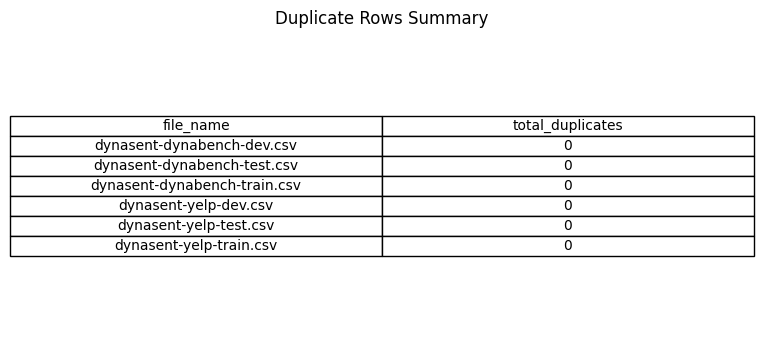

In [32]:
def print_duplicate_rows_summary():
    # Directory containing the CSV files
    csv_dir = "modified_data"

    # List to store the results
    duplicate_rows_summary = []

    # Iterate through each CSV file in the directory
    for file_name in os.listdir(csv_dir):
        if file_name.endswith(".csv"):
            file_path = os.path.join(csv_dir, file_name)
            df = pd.read_csv(file_path)

            # Count duplicate rows in 'text' column
            duplicate_rows = df[df.duplicated(subset=['text'], keep=False)]

            # Append the results to the summary list
            duplicate_rows_summary.append({
                'file_name': file_name,
                'total_duplicates': len(duplicate_rows)
            })

    # Convert the summary list to a DataFrame for better visualization
    duplicate_rows_df = pd.DataFrame(duplicate_rows_summary)

    # Plot the table
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=duplicate_rows_df.values, colLabels=duplicate_rows_df.columns, cellLoc='center', loc='center')
    ax.set_title('Duplicate Rows Summary')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.2)
    plt.show()

# Call the function to print the duplicate rows summary
print_duplicate_rows_summary()

## Check for any other labels

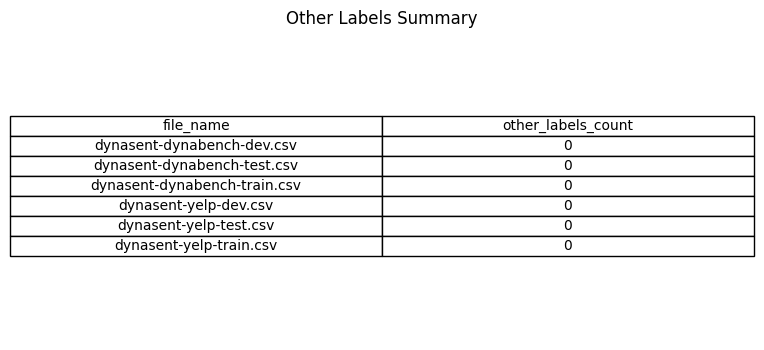

In [33]:
def check_other_labels():
    # Directory containing the CSV files
    csv_dir = "modified_data"

    # List to store the results
    other_labels_summary = []

    # Iterate through each CSV file in the directory
    for file_name in os.listdir(csv_dir):
        if file_name.endswith(".csv"):
            file_path = os.path.join(csv_dir, file_name)
            df = pd.read_csv(file_path)

            # Filter rows with labels other than 'positive', 'negative', 'neutral', and 'mixed'
            other_labels_df = df[~df['label'].isin(['positive', 'negative', 'neutral', 'mixed'])]

            # Count the number of such rows
            other_labels_count = len(other_labels_df)

            # Append the results to the summary list
            other_labels_summary.append({
                'file_name': file_name,
                'other_labels_count': other_labels_count
            })

    # Convert the summary list to a DataFrame for better visualization
    other_labels_summary_df = pd.DataFrame(other_labels_summary)

    # Plot the table
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=other_labels_summary_df.values, colLabels=other_labels_summary_df.columns, cellLoc='center', loc='center')
    ax.set_title('Other Labels Summary')
    table.auto_set_font_size(True)
    table.set_fontsize(10)
    table.scale(1.2, 1.2)
    plt.show()

# Call the function to check for other labels
check_other_labels()

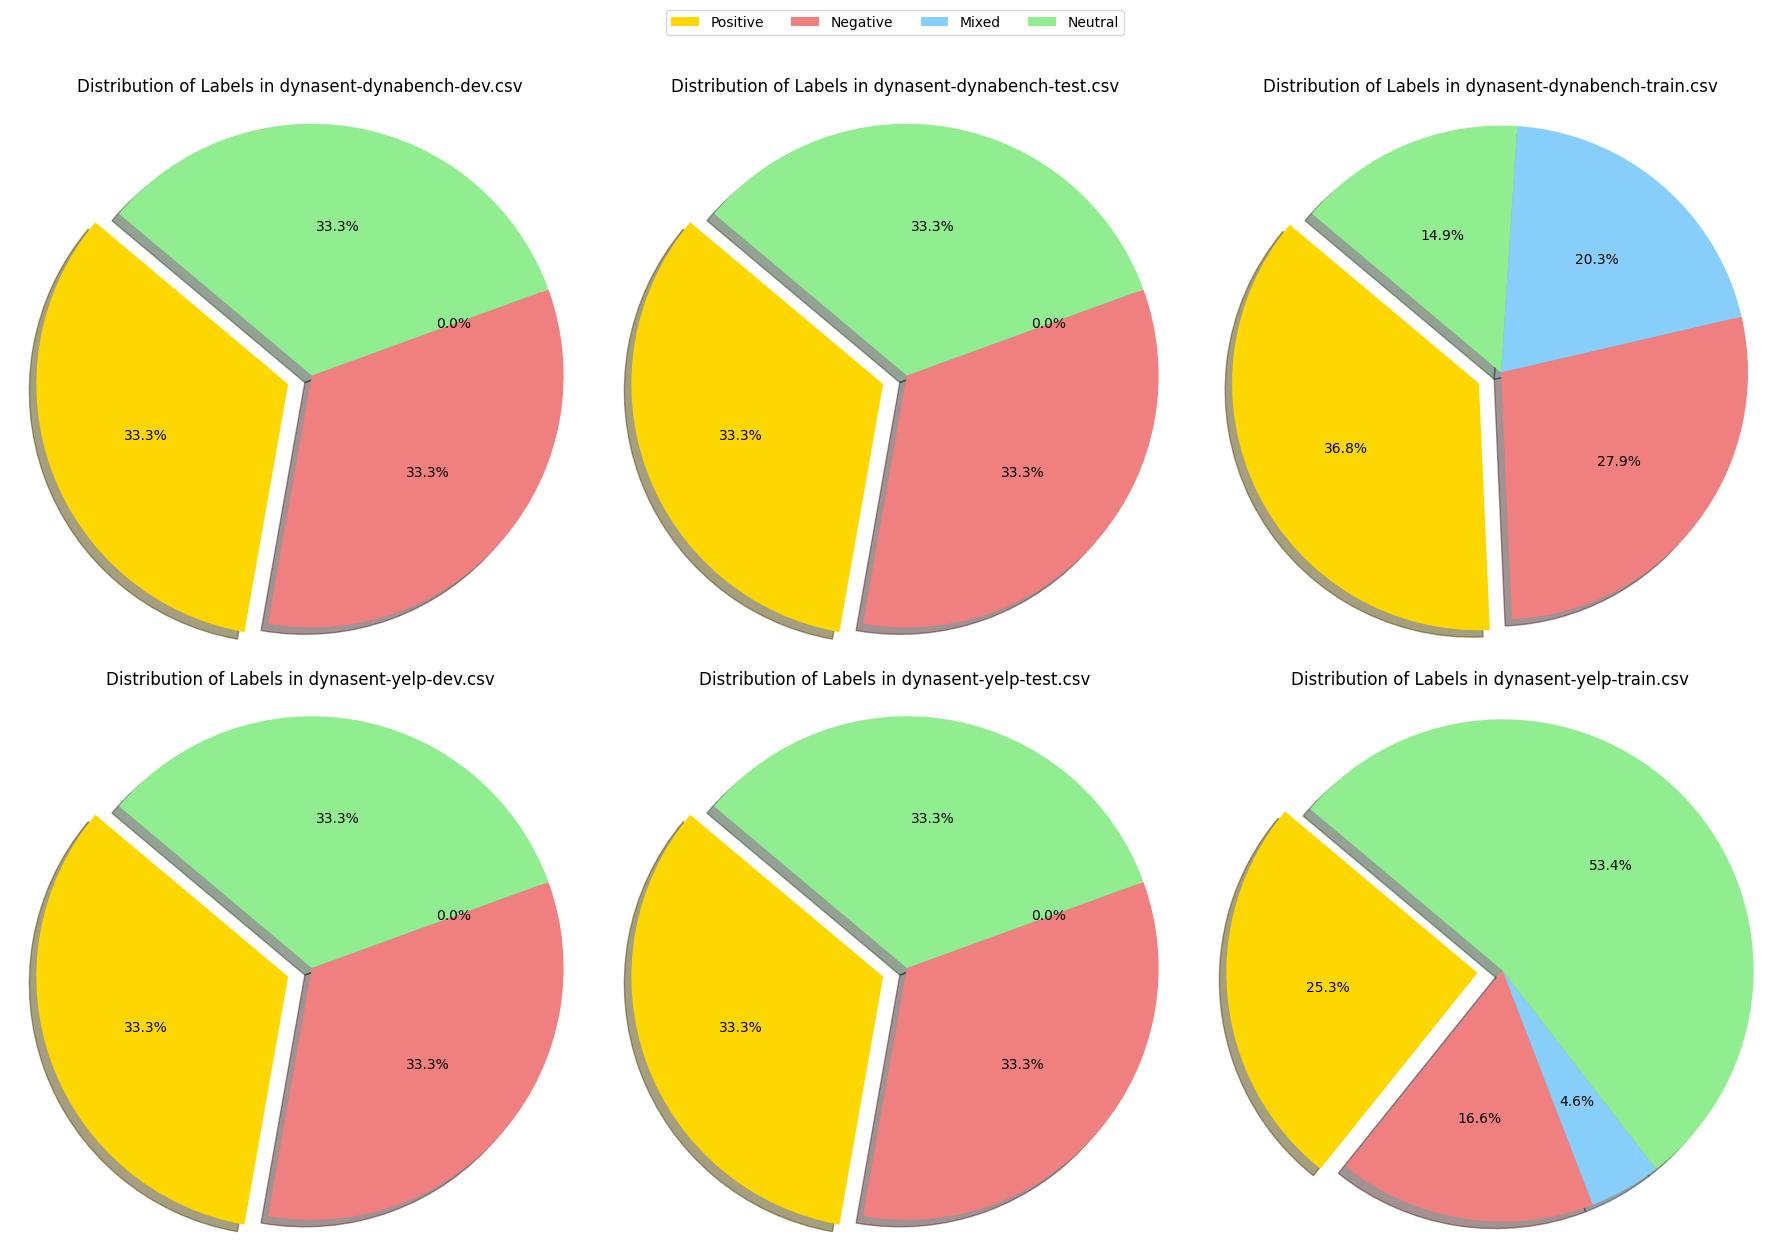

In [49]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Define labels and colors for the legend
labels = ['Positive', 'Negative', 'Mixed', 'Neutral']
colors = ['gold', 'lightcoral', 'lightskyblue', 'lightgreen']

for index, (ax, row) in enumerate(zip(axes, rows_summary_df.iterrows())):
    sizes = [row[1]['positive_rows'], row[1]['negative_rows'], row[1]['mixed_rows'], row[1]['neutral_rows']]
    explode = (0.1, 0, 0, 0)  # explode 1st slice

    ax.pie(sizes, explode=explode, colors=colors,
           autopct='%1.1f%%', shadow=True, startangle=140)
    ax.set_title(f'Distribution of Labels in {row[1]["file_name"]}')
    ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Hide any unused subplots
for i in range(index + 1, len(axes)):
    fig.delaxes(axes[i])

# Add a legend at the top
fig.legend(labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.show()

### after going thorugh the distribution, i thought to remove the mixed label from both the train sets as its not there in the dev and test set.

### Then i thought to combine both the train sets, to increase the dataset as both have same content of text.
-------------------------------------------------------------------------------------------------------------------

## Removing mixed labels

In [50]:
# Directory containing the CSV files
csv_dir = "modified_data"

# Iterate through each CSV file in the directory
for file_name in os.listdir(csv_dir):
    if file_name.endswith(".csv") and 'train' in file_name:
        file_path = os.path.join(csv_dir, file_name)
        df = pd.read_csv(file_path)
        
        # Remove rows with 'mixed' label
        df = df[df['label'] != 'mixed']
        
        # Save the cleaned dataframe to a new CSV file
        new_file_path = os.path.join(csv_dir, f"new-{file_name}")
        df.to_csv(new_file_path, index=False)

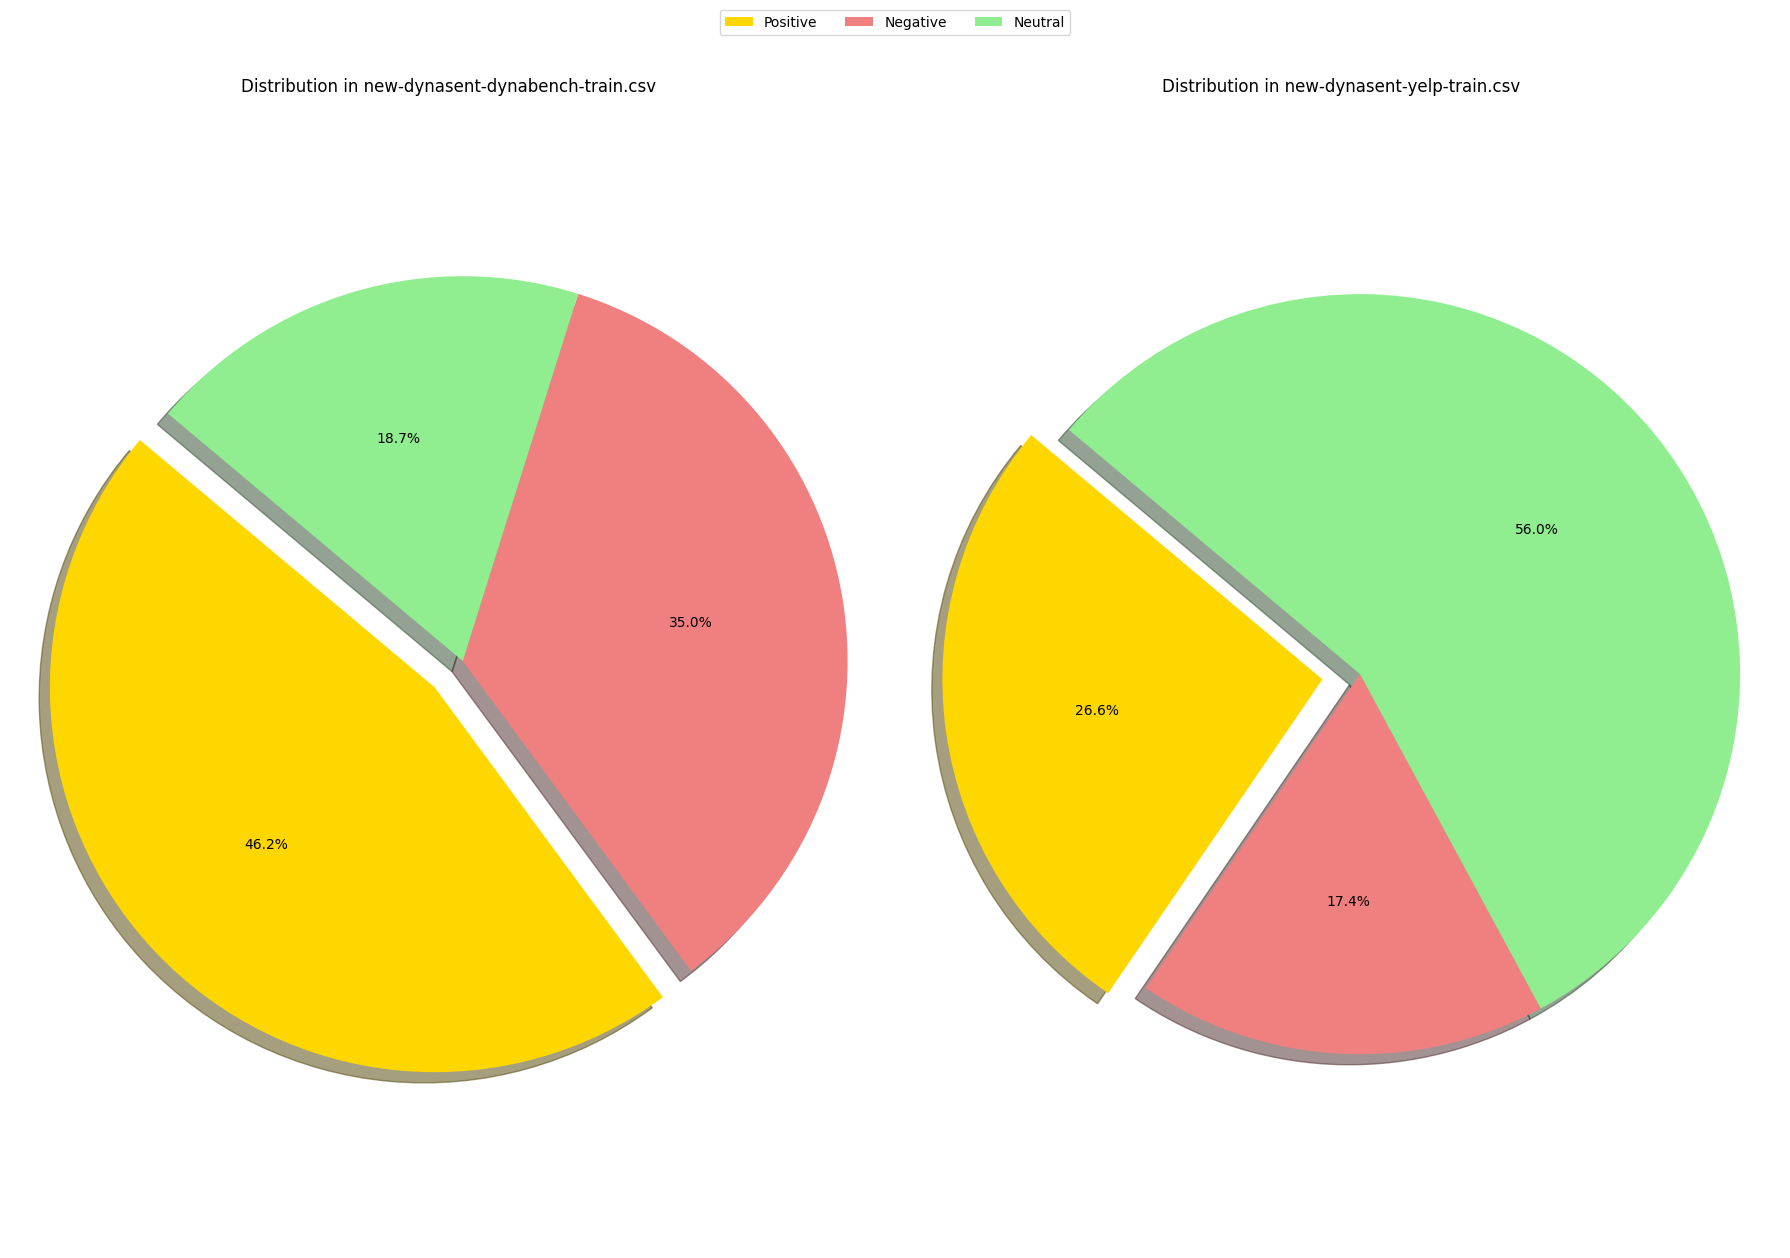

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(18, 12))
axes = axes.flatten()

# Define labels and colors for the legend
labels = ['Positive', 'Negative', 'Neutral']
colors = ['gold', 'lightcoral', 'lightgreen']

csv_dir = "modified_data"
csv_files = [file for file in os.listdir(csv_dir) if file.endswith(".csv") and 'train' in file and file.startswith("new")]

for index, (ax, file_name) in enumerate(zip(axes, csv_files)):
    file_path = os.path.join(csv_dir, file_name)
    df = pd.read_csv(file_path)
    
    sizes = [
        len(df[df['label'] == 'positive']),
        len(df[df['label'] == 'negative']),
        len(df[df['label'] == 'neutral'])
    ]
    explode = (0.1, 0, 0)  # explode 1st slice

    ax.pie(sizes, explode=explode, colors=colors,
           autopct='%1.1f%%', shadow=True, startangle=140)
    ax.set_title(f'Distribution in {file_name}')
    ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Hide any unused subplots
for i in range(index + 1, len(axes)):
    fig.delaxes(axes[i])

# Add a legend at the top
fig.legend(labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.show()

# Combining both yelp and dynabench dataset

In [55]:
# Directory containing the CSV files
csv_dir = "modified_data"
combined_dir = "combined_data"

# Initialize empty DataFrames to store the combined data
combined_train_df = pd.DataFrame()
combined_test_df = pd.DataFrame()
combined_dev_df = pd.DataFrame()

# Iterate through each CSV file in the directory
for file_name in os.listdir(csv_dir):
    file_path = os.path.join(csv_dir, file_name)
    df = pd.read_csv(file_path)
    
    if file_name.endswith(".csv") and file_name.startswith("new-") and 'train' in file_name:
        # Append the data to the combined train DataFrame
        combined_train_df = pd.concat([combined_train_df, df], ignore_index=True)
    elif file_name.endswith(".csv") and 'test' in file_name:
        # Append the data to the combined test DataFrame
        combined_test_df = pd.concat([combined_test_df, df], ignore_index=True)
    elif file_name.endswith(".csv") and 'dev' in file_name:
        # Append the data to the combined dev DataFrame
        combined_dev_df = pd.concat([combined_dev_df, df], ignore_index=True)

# Save the combined DataFrames to new CSV files
os.makedirs(combined_dir, exist_ok=True)
combined_train_file_path = os.path.join(combined_dir, "combined_train_data.csv")
combined_train_df.to_csv(combined_train_file_path, index=False)

combined_test_file_path = os.path.join(combined_dir, "combined_test_data.csv")
combined_test_df.to_csv(combined_test_file_path, index=False)

combined_dev_file_path = os.path.join(combined_dir, "combined_dev_data.csv")
combined_dev_df.to_csv(combined_dev_file_path, index=False)

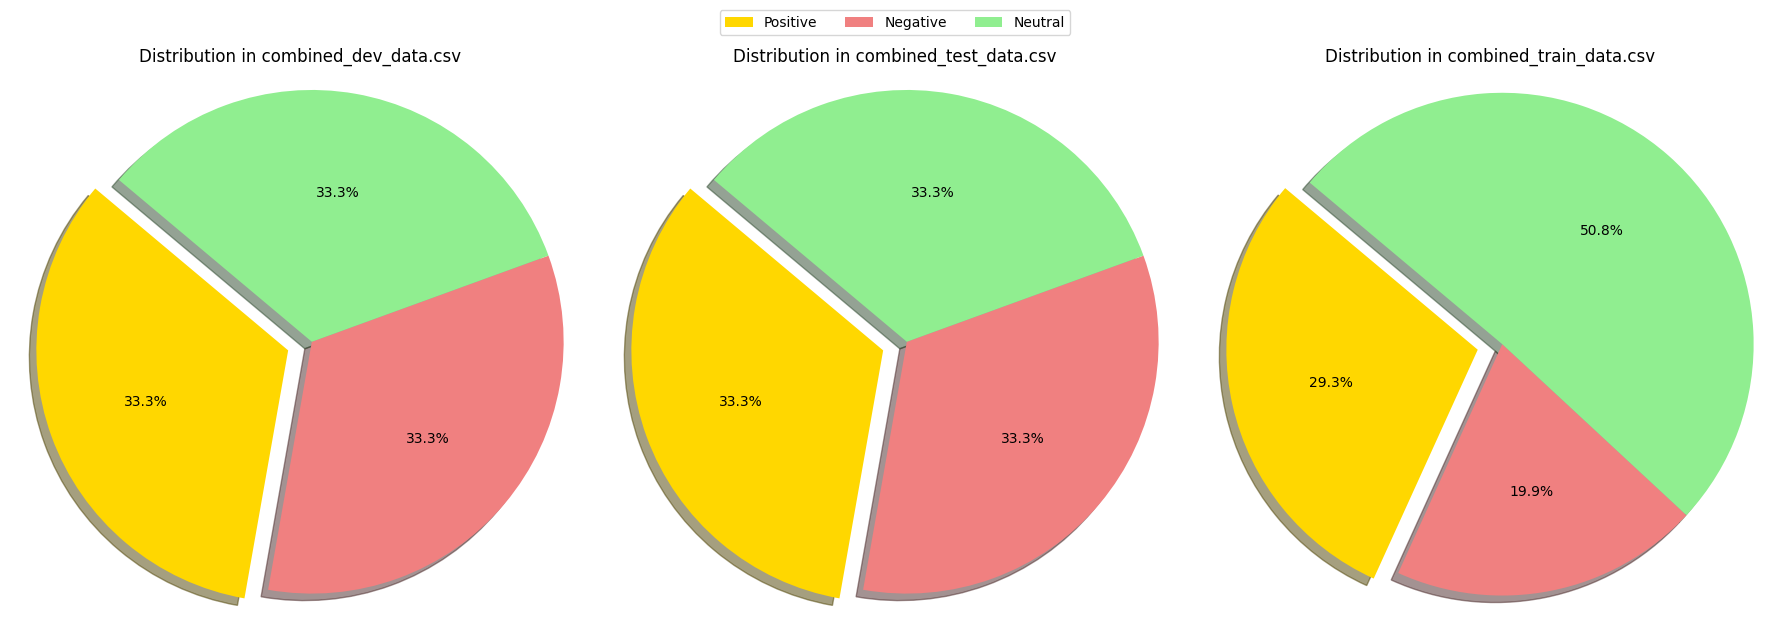

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

# Define labels and colors for the legend
labels = ['Positive', 'Negative', 'Neutral']
colors = ['gold', 'lightcoral', 'lightgreen']

combined_dir = "combined_data"
combined_files = [file for file in os.listdir(combined_dir) if file.endswith(".csv")]

for index, (ax, file_name) in enumerate(zip(axes, combined_files)):
    file_path = os.path.join(combined_dir, file_name)
    df = pd.read_csv(file_path)
    
    sizes = [
        len(df[df['label'] == 'positive']),
        len(df[df['label'] == 'negative']),
        len(df[df['label'] == 'neutral'])
    ]
    explode = (0.1, 0, 0)  # explode 1st slice

    ax.pie(sizes, explode=explode, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
    ax.set_title(f'Distribution in {file_name}')
    ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Hide any unused subplots
for i in range(index + 1, len(axes)):
    fig.delaxes(axes[i])

# Add a legend at the top
fig.legend(labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.show()


In [67]:
def downsample_dataframe(file_path):
    df = pd.read_csv(file_path)

    # Separate the dataframe into different label dataframes
    positive_df = df[df['label'] == 'positive']
    neutral_df = df[df['label'] == 'neutral']
    negative_df = df[df['label'] == 'negative']

    # Get the minimum number of rows among the three labels
    min_count = min(len(positive_df), len(neutral_df), len(negative_df))

    # Shuffle and downsample the positive and neutral dataframes
    positive_df = positive_df.sample(n=min_count, random_state=42)
    neutral_df = neutral_df.sample(n=min_count, random_state=42)
    negative_df = negative_df.sample(n=min_count, random_state=42)

    # Combine the dataframes back together
    downsampled_df = pd.concat([positive_df, neutral_df, negative_df], ignore_index=True)

    # Shuffle the combined dataframe
    downsampled_df = downsampled_df.sample(frac=1, random_state=42).reset_index(drop=True)

    # Count the number of rows for each label
    label_counts = downsampled_df['label'].value_counts()
    print(label_counts)

    return downsampled_df

# Example usage
file_path_1 = "modified_data/new-dynasent-yelp-train.csv"
downsampled_df_1 = downsample_dataframe(file_path_1)

file_path_2 = "modified_data/new-dynasent-dynabench-train.csv"
downsampled_df_2 = downsample_dataframe(file_path_2)

# Save the downsampled dataframes to new CSV files
downsampled_file_path_1 = os.path.join("final_data\yelp", "train.csv")
downsampled_df_1.to_csv(downsampled_file_path_1, index=False)

downsampled_file_path_2 = os.path.join("final_data\dynabench", "train.csv")
downsampled_df_2.to_csv(downsampled_file_path_2, index=False)

<>:37: SyntaxWarning: invalid escape sequence '\y'
<>:40: SyntaxWarning: invalid escape sequence '\d'
<>:37: SyntaxWarning: invalid escape sequence '\y'
<>:40: SyntaxWarning: invalid escape sequence '\d'
C:\Users\neerajdattu.dudam\AppData\Local\Temp\ipykernel_10180\1921788666.py:37: SyntaxWarning: invalid escape sequence '\y'
  downsampled_file_path_1 = os.path.join("final_data\yelp", "train.csv")
C:\Users\neerajdattu.dudam\AppData\Local\Temp\ipykernel_10180\1921788666.py:40: SyntaxWarning: invalid escape sequence '\d'
  downsampled_file_path_2 = os.path.join("final_data\dynabench", "train.csv")


label
negative    14021
neutral     14021
positive    14021
Name: count, dtype: int64
label
negative    2448
positive    2448
neutral     2448
Name: count, dtype: int64


In [68]:
def combine_and_shuffle(file_path_1, file_path_2):
    # Read the two downsampled dataframes
    df1 = pd.read_csv(file_path_1)
    df2 = pd.read_csv(file_path_2)

    # Combine the two dataframes
    combined_df = pd.concat([df1, df2], ignore_index=True)

    # Shuffle the combined dataframe
    combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

    label_counts = combined_df['label'].value_counts()
    print(label_counts)

    return combined_df
    

# Example usage
train_combined = combine_and_shuffle("final_data/yelp/train.csv", "final_data/dynabench/train.csv")
# Save the combined and shuffled dataframe to a new CSV file
combined_train_file_path = os.path.join("final_data\yelp_dynabench_2500", "train.csv")
train_combined.to_csv(combined_train_file_path, index=False)


<>:21: SyntaxWarning: invalid escape sequence '\y'
<>:21: SyntaxWarning: invalid escape sequence '\y'
C:\Users\neerajdattu.dudam\AppData\Local\Temp\ipykernel_10180\695411791.py:21: SyntaxWarning: invalid escape sequence '\y'
  combined_train_file_path = os.path.join("final_data\yelp_dynabench_2500", "train.csv")


label
neutral     16469
negative    16469
positive    16469
Name: count, dtype: int64


In [71]:
def shuffle_and_downsample(file_path, n_samples=240):
    df = pd.read_csv(file_path)

    # Separate the dataframe into different label dataframes
    positive_df = df[df['label'] == 'positive']
    neutral_df = df[df['label'] == 'neutral']
    negative_df = df[df['label'] == 'negative']

    # Downsample each label dataframe to n_samples
    positive_df = positive_df.sample(n=n_samples, random_state=42)
    neutral_df = neutral_df.sample(n=n_samples, random_state=42)
    negative_df = negative_df.sample(n=n_samples, random_state=42)

    # Combine the dataframes back together
    downsampled_df = pd.concat([positive_df, neutral_df, negative_df], ignore_index=True)

    # Shuffle the combined dataframe
    downsampled_df = downsampled_df.sample(frac=1, random_state=42).reset_index(drop=True)

    # Count the number of rows for each label
    label_counts = downsampled_df['label'].value_counts()
    print(label_counts)

    return downsampled_df

# Example usage
yelp_test_path = r"final_data/yelp/test.csv"
downsampled_yelp_test = shuffle_and_downsample(yelp_test_path)

yelp_dev_path = r"final_data/yelp/dev.csv"
downsampled_yelp_dev = shuffle_and_downsample(yelp_dev_path)

dynabench_test_path = r"final_data/dynabench/test.csv"
dynabench_test_df = pd.read_csv(dynabench_test_path)

dynabench_dev_path = r"final_data/dynabench/dev.csv"
dynabench_dev_df = pd.read_csv(dynabench_dev_path)

# Combine yelp and dynabench test dataframes
combined_test_df = pd.concat([downsampled_yelp_test, dynabench_test_df], ignore_index=True)

# Shuffle the combined test dataframe
combined_test_df = combined_test_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save the combined and shuffled test dataframe to a new CSV file
combined_test_file_path = os.path.join("final_data/yelp_dynabench_2500", "test.csv")
combined_test_df.to_csv(combined_test_file_path, index=False)

# Combine yelp and dynabench dev dataframes
combined_dev_df = pd.concat([downsampled_yelp_dev, dynabench_dev_df], ignore_index=True)

# Shuffle the combined dev dataframe
combined_dev_df = combined_dev_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save the combined and shuffled dev dataframe to a new CSV file
combined_dev_file_path = os.path.join("final_data/yelp_dynabench_2500", "dev.csv")
combined_dev_df.to_csv(combined_dev_file_path, index=False)

label
neutral     240
positive    240
negative    240
Name: count, dtype: int64
label
neutral     240
positive    240
negative    240
Name: count, dtype: int64
